In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\abhin\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [7]:
import os

print("Jupyter folder:")
print(os.getcwd())

print("\nFiles visible to Jupyter:")
for file in os.listdir():
    print(file)

Jupyter folder:
C:\Users\abhin\project_revature

Files visible to Jupyter:
.ipynb_checkpoints
data_cleaning.ipynb
data_visualization.ipynb
deliveries.csv
deliveries_cleaned.csv
matches.csv
matches_cleaned.csv


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

folder = Path(r"C:\Users\abhin\OneDrive\Documents\project_revature")  # Replace with your actual folder path

matches_per_season = pd.read_csv(folder / "matches_per_season.csv")
player_of_the_match = pd.read_csv(folder / "player_of_the_match.csv")
top_10_batters = pd.read_csv(folder / "top_10_batters.csv")
top_10_bowlers = pd.read_csv(folder / "top_10_bowlers.csv")
top_10_venues = pd.read_csv(folder / "top_10_venues.csv")
toss_decision = pd.read_csv(folder / "toss_decision.csv")
total_wins = pd.read_csv(folder / "total_wins.csv")

print("All seven files loaded successfully!")

All seven files loaded successfully!


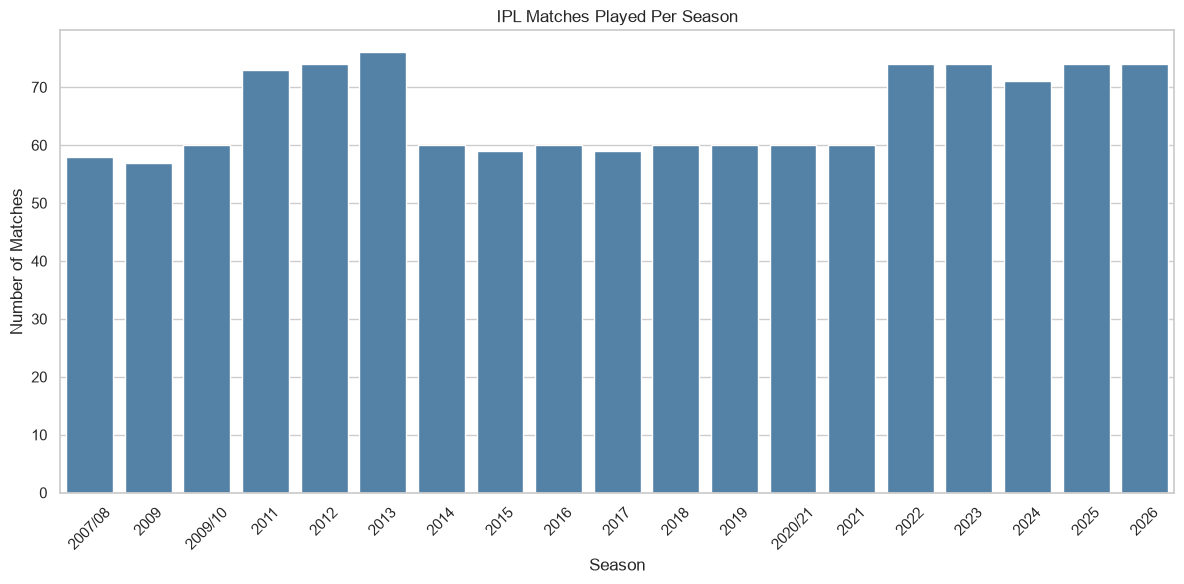

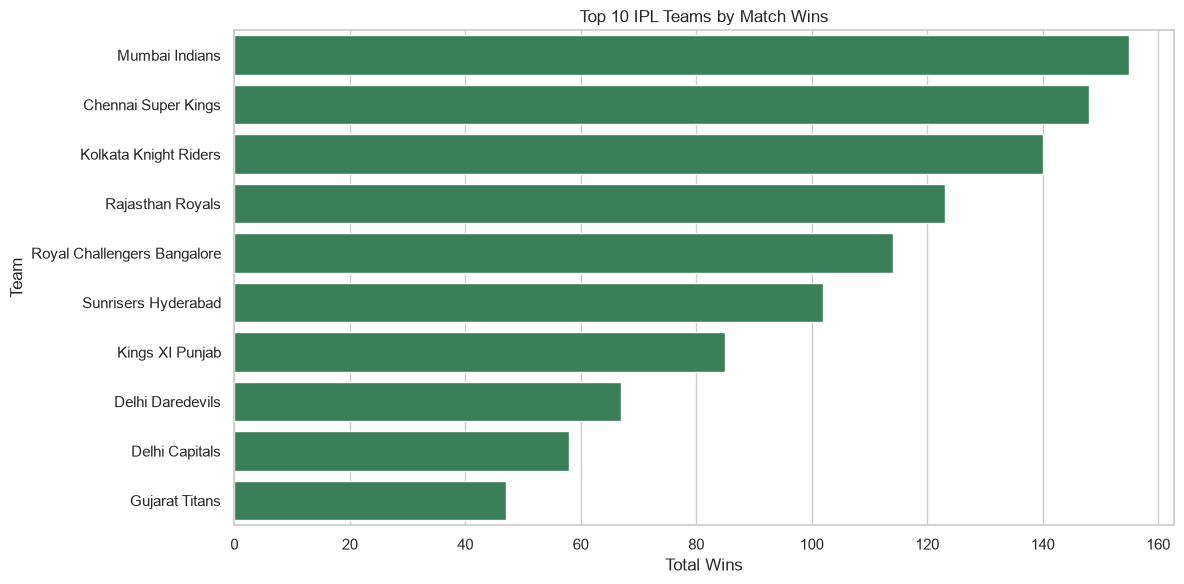

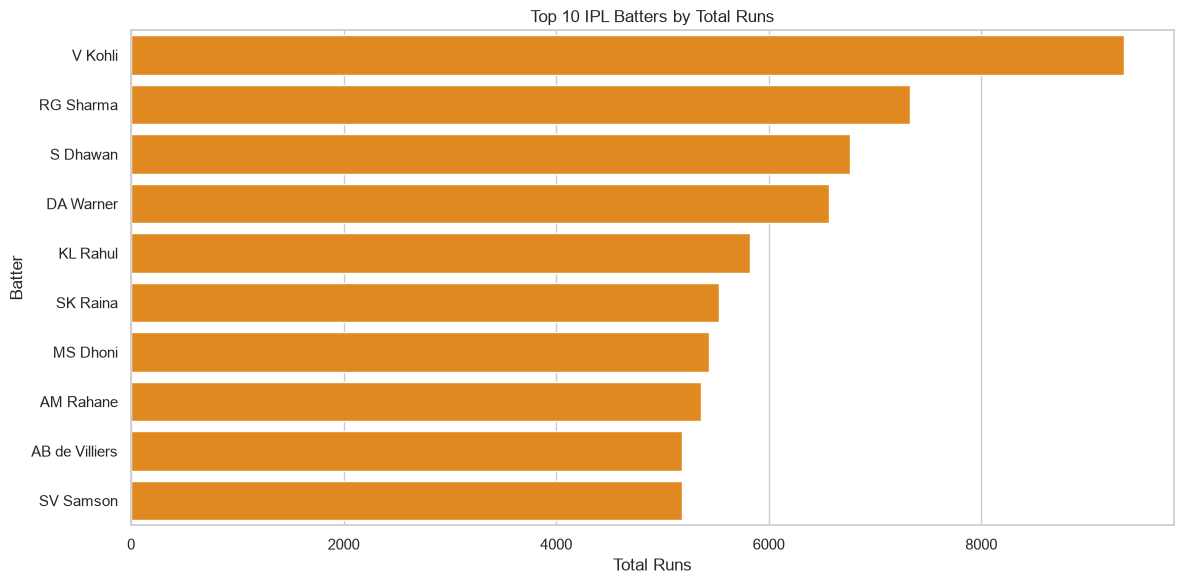

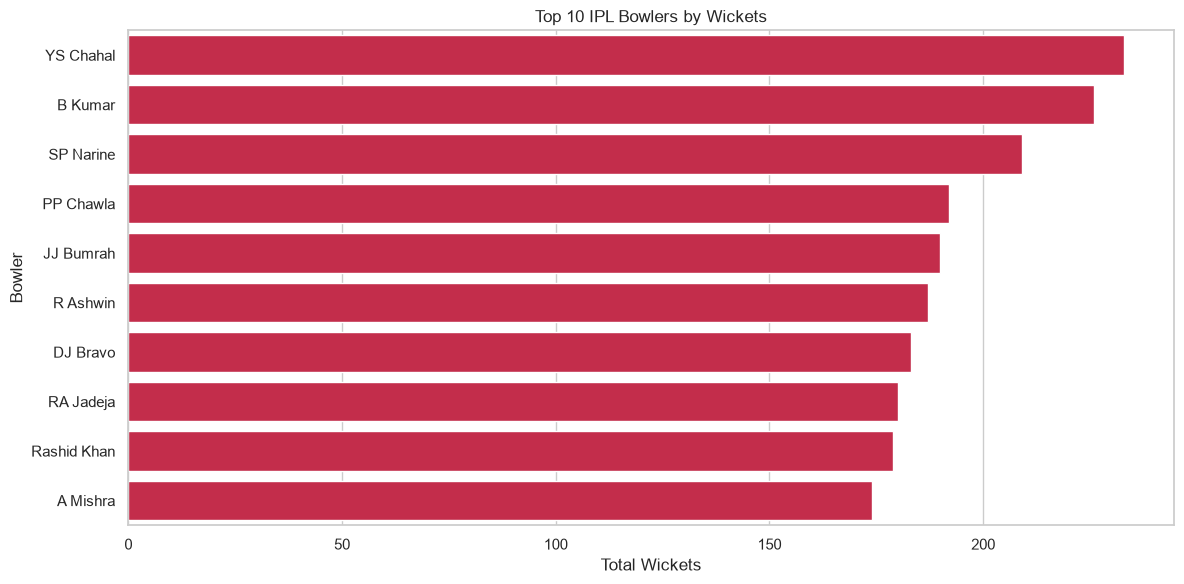

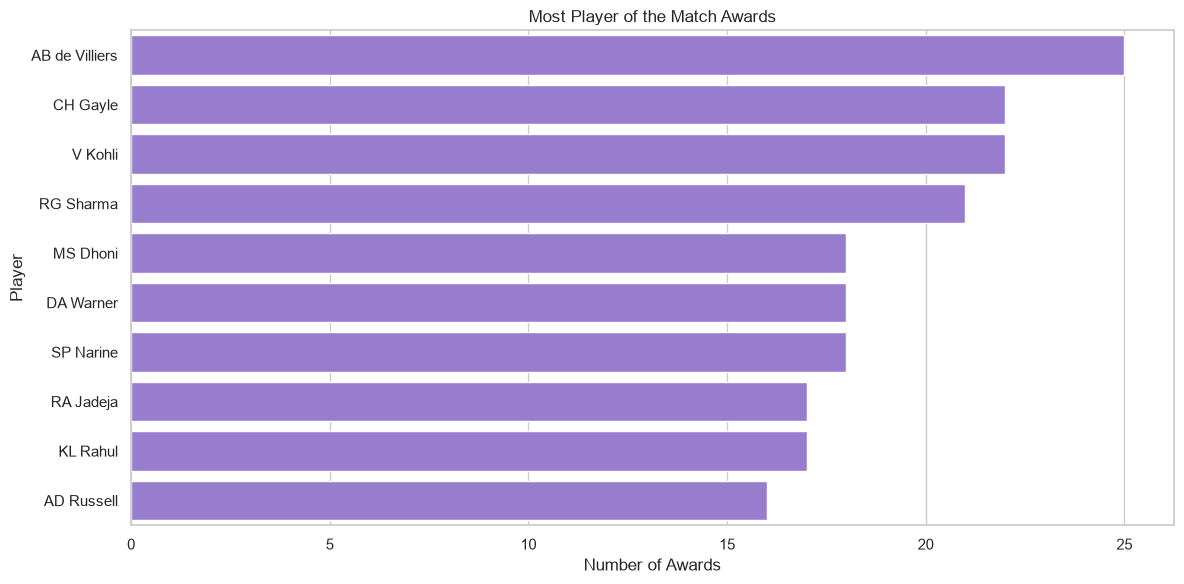

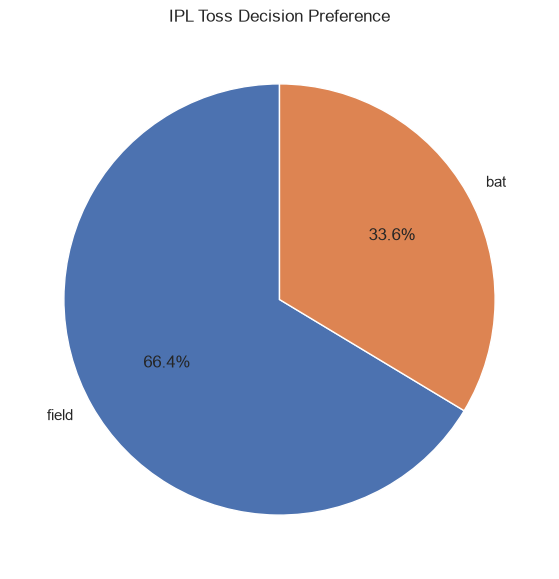

Text(0, 0.5, 'Venue')

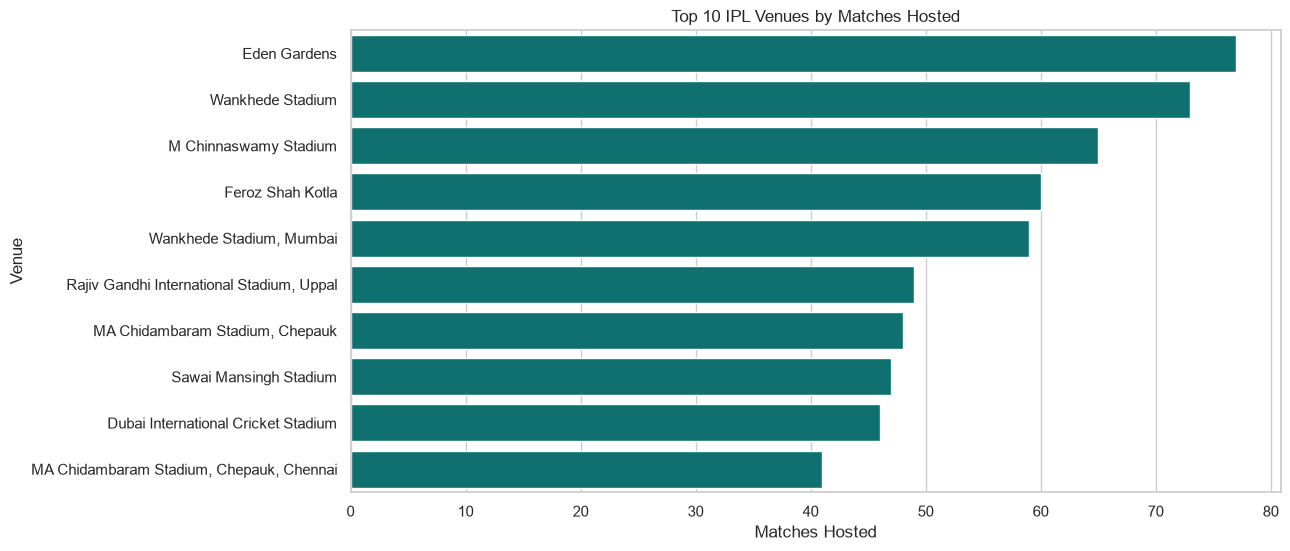

In [11]:
# 1. Matches per season
plt.figure(figsize=(12, 6))
sns.barplot(data=matches_per_season, x="season", y="total_matches", color="steelblue")
plt.title("IPL Matches Played Per Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Top teams by wins
plt.figure(figsize=(12, 6))
sns.barplot(data=total_wins.head(10), x="total_wins", y="team", color="seagreen")
plt.title("Top 10 IPL Teams by Match Wins")
plt.xlabel("Total Wins")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

# 3. Top batters
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_batters, x="total_runs", y="batter", color="darkorange")
plt.title("Top 10 IPL Batters by Total Runs")
plt.xlabel("Total Runs")
plt.ylabel("Batter")
plt.tight_layout()
plt.show()

# 4. Top bowlers
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_bowlers, x="total_wickets", y="bowler", color="crimson")
plt.title("Top 10 IPL Bowlers by Wickets")
plt.xlabel("Total Wickets")
plt.ylabel("Bowler")
plt.tight_layout()
plt.show()

# 5. Player of the Match awards
plt.figure(figsize=(12, 6))
sns.barplot(data=player_of_the_match, x="awards", y="player_of_match", color="mediumpurple")
plt.title("Most Player of the Match Awards")
plt.xlabel("Number of Awards")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

# 6. Toss decision pie chart
plt.figure(figsize=(7, 7))
plt.pie(
    toss_decision["times_chosen"],
    labels=toss_decision["toss_decision"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("IPL Toss Decision Preference")
plt.show()

# 7. Top venues
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_venues, x="matches_hosted", y="venue", color="teal")
plt.title("Top 10 IPL Venues by Matches Hosted")
plt.xlabel("Matches Hosted")
plt.ylabel("Venue")


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

matches = pd.read_csv("matches_cleaned.csv", low_memory=False)
deliveries = pd.read_csv("deliveries_cleaned.csv", low_memory=False)

matches["date"] = pd.to_datetime(matches["date"], errors="coerce")
deliveries["date"] = pd.to_datetime(deliveries["date"], errors="coerce")

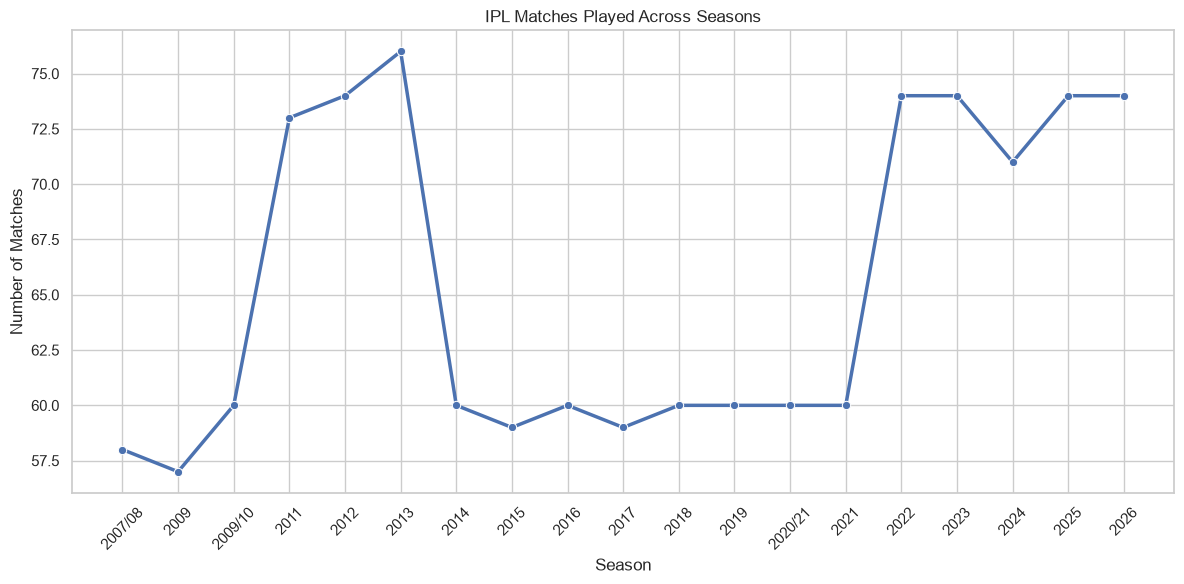

In [13]:
#Line chart — IPL matches across seasons

season_count = matches.groupby("season").size().reset_index(name="matches")

plt.figure(figsize=(12, 6))
sns.lineplot(data=season_count, x="season", y="matches", marker="o", linewidth=2.5)

plt.title("IPL Matches Played Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

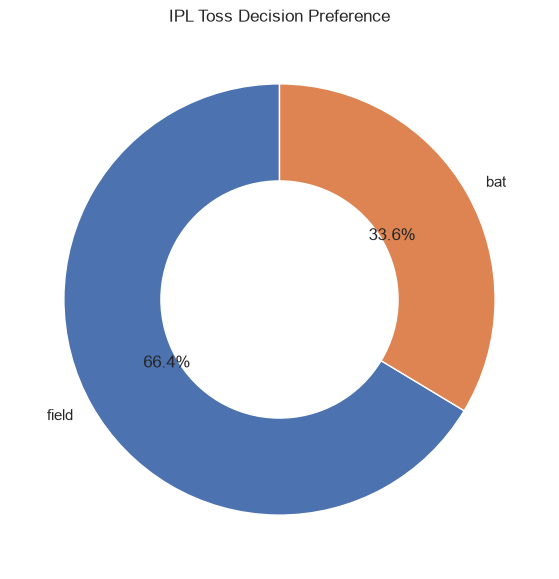

In [15]:



# Donut chart — Toss decision: bat or field
toss_count = matches["toss_decision"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    toss_count.values,
    labels=toss_count.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.45}
)

plt.title("IPL Toss Decision Preference")
plt.show()

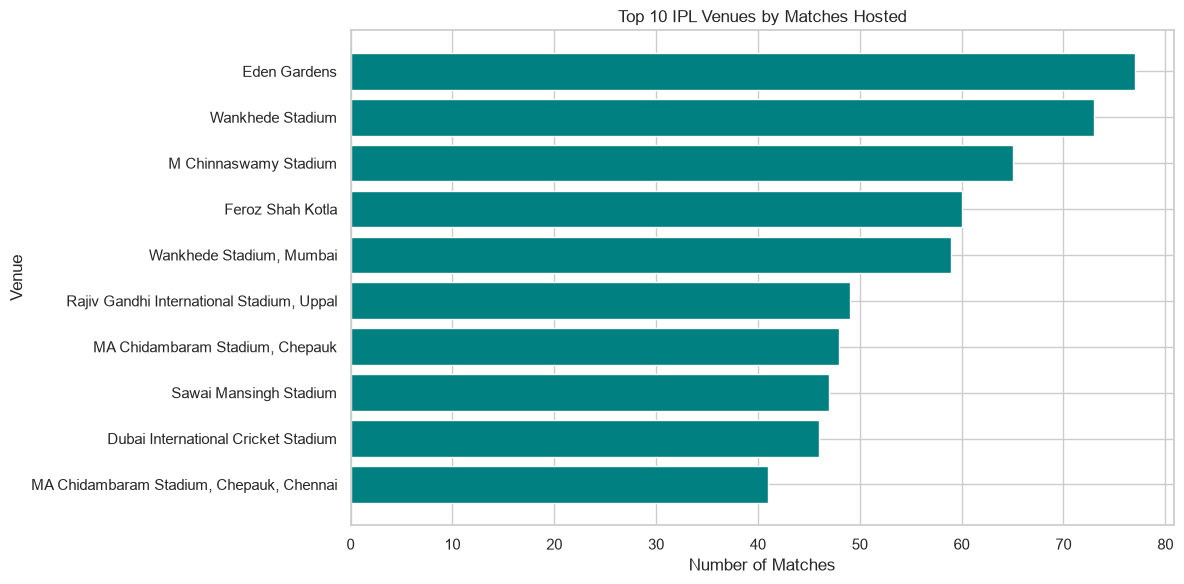

In [16]:
#Horizontal bar chart — Top IPL venues

venue_count = matches["venue"].value_counts().head(10).sort_values()

plt.figure(figsize=(12, 6))
plt.barh(venue_count.index, venue_count.values, color="teal")

plt.title("Top 10 IPL Venues by Matches Hosted")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")
plt.tight_layout()
plt.show()

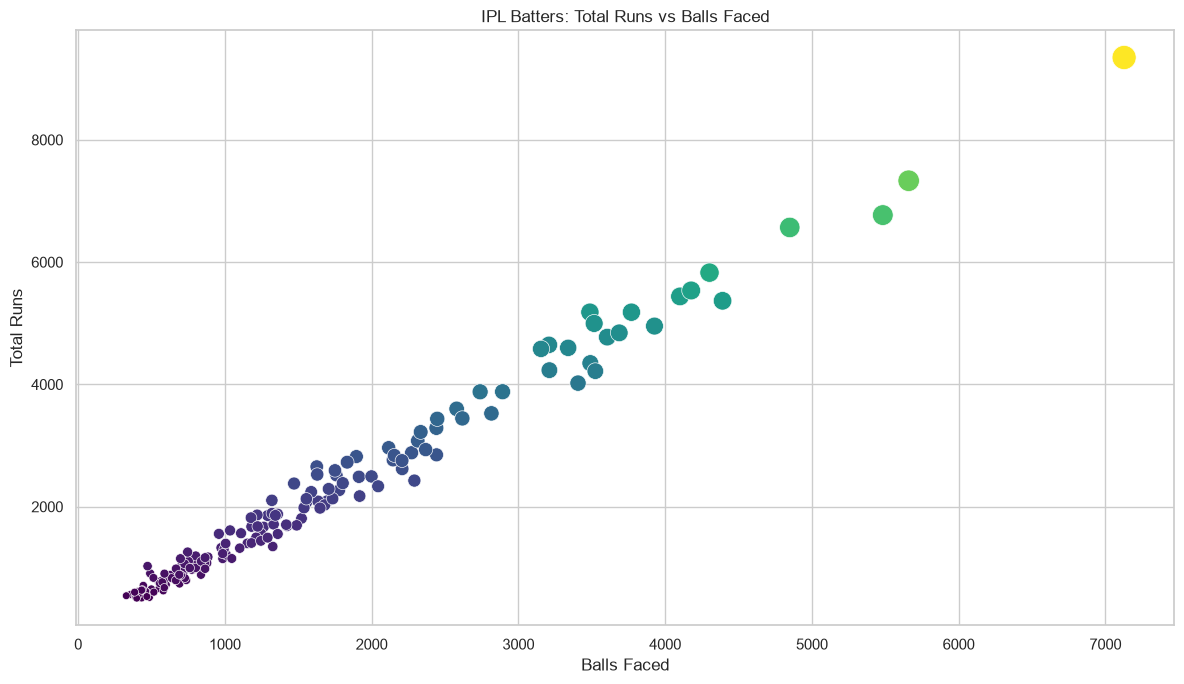

In [17]:
#Scatter plot — Runs scored vs balls faced

batter_stats = (
    deliveries.groupby("striker")
    .agg(
        total_runs=("runs_off_bat", "sum"),
        balls_faced=("runs_off_bat", "count")
    )
    .reset_index()
)

# Show players with at least 500 runs
batter_stats = batter_stats[batter_stats["total_runs"] >= 500]

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=batter_stats,
    x="balls_faced",
    y="total_runs",
    size="total_runs",
    hue="total_runs",
    palette="viridis",
    sizes=(30, 300),
    legend=False
)

plt.title("IPL Batters: Total Runs vs Balls Faced")
plt.xlabel("Balls Faced")
plt.ylabel("Total Runs")
plt.tight_layout()
plt.show()

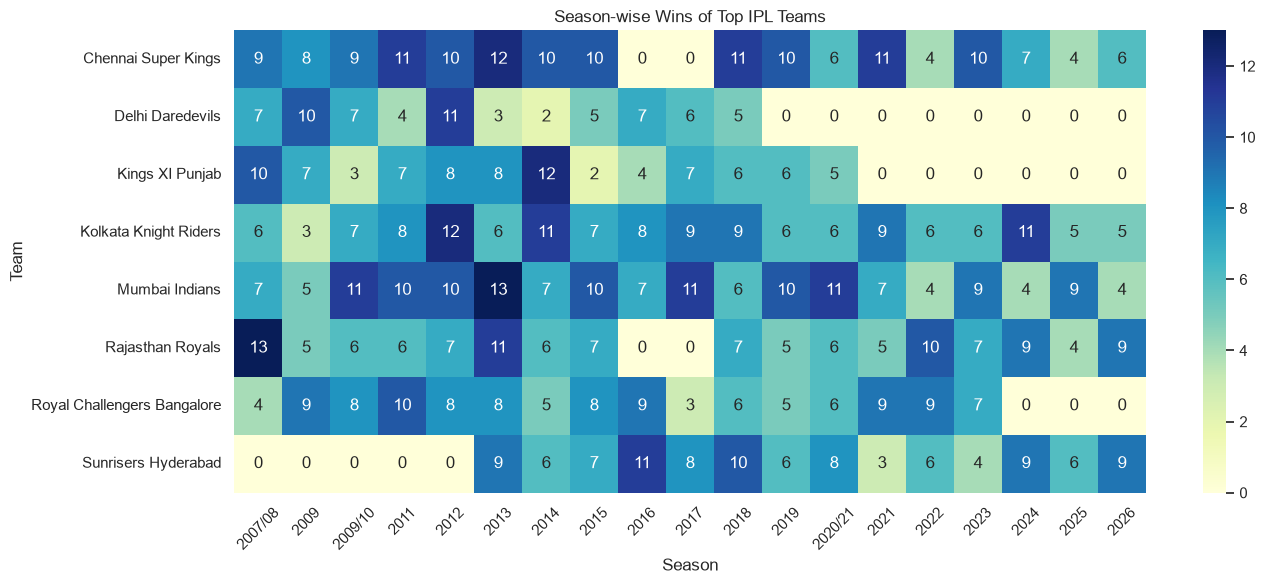

In [18]:
#Heatmap — Top teams’ wins by season
top_teams = matches["winner"].value_counts().head(8).index

team_season_wins = matches[matches["winner"].isin(top_teams)].pivot_table(
    index="winner",
    columns="season",
    values="match_id",
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(14, 6))
sns.heatmap(team_season_wins, annot=True, fmt="g", cmap="YlGnBu")

plt.title("Season-wise Wins of Top IPL Teams")
plt.xlabel("Season")
plt.ylabel("Team")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

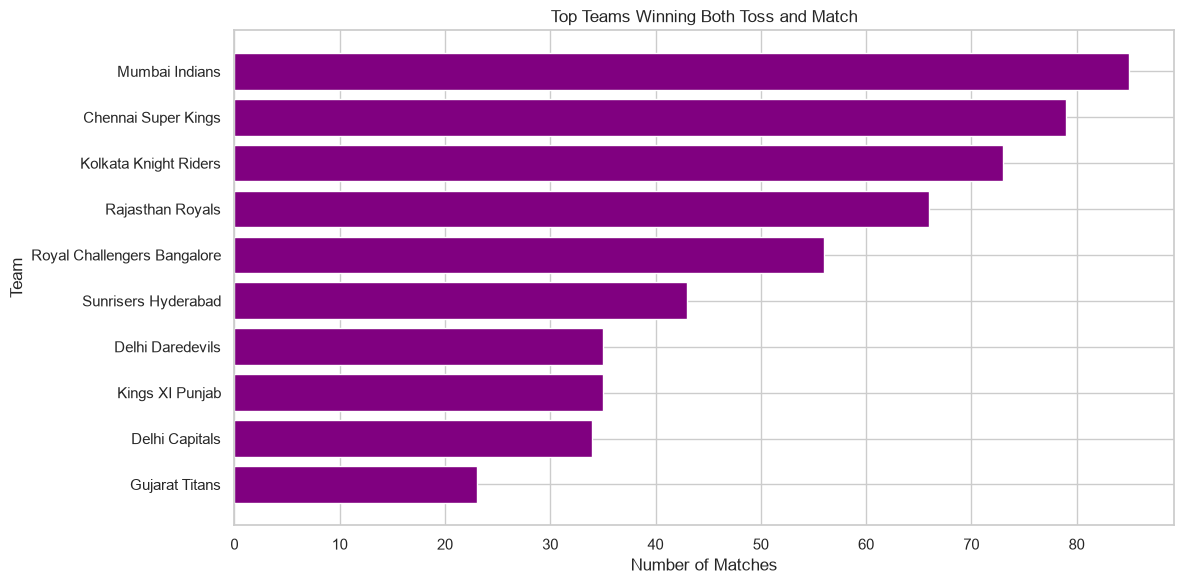

In [19]:
#Grouped bar chart — Toss winners who also won the match
toss_match_wins = matches[matches["toss_winner"] == matches["winner"]]

top_toss_winners = toss_match_wins["winner"].value_counts().head(10).sort_values()

plt.figure(figsize=(12, 6))
plt.barh(top_toss_winners.index, top_toss_winners.values, color="purple")

plt.title("Top Teams Winning Both Toss and Match")
plt.xlabel("Number of Matches")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

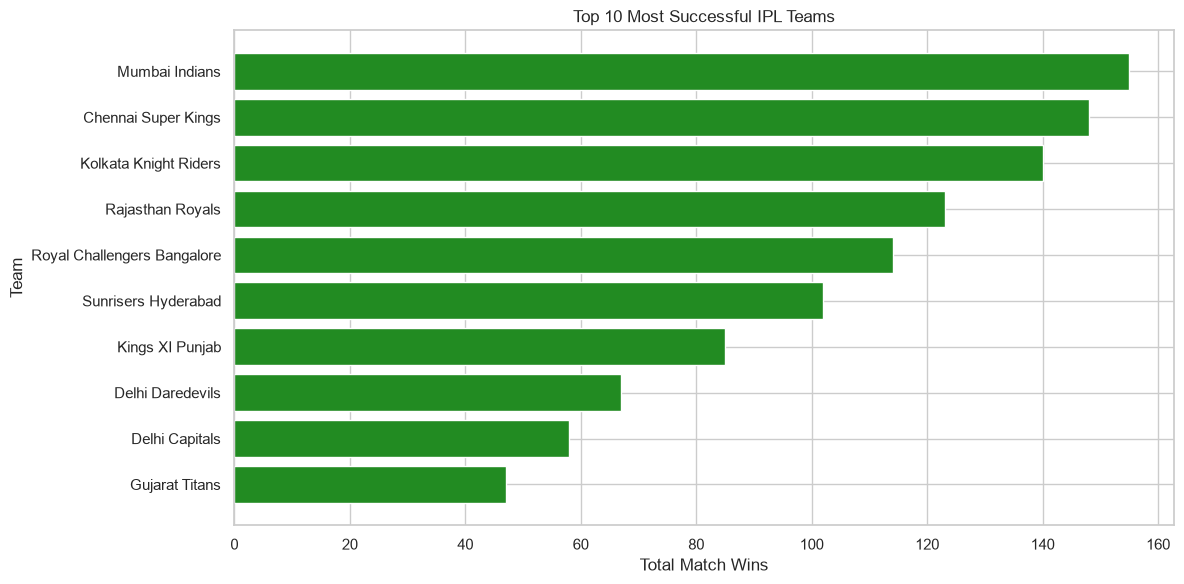

In [20]:
#Most successful teams — total wins

team_wins = matches["winner"].value_counts().head(10).sort_values()

plt.figure(figsize=(12, 6))
plt.barh(team_wins.index, team_wins.values, color="forestgreen")

plt.title("Top 10 Most Successful IPL Teams")
plt.xlabel("Total Match Wins")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

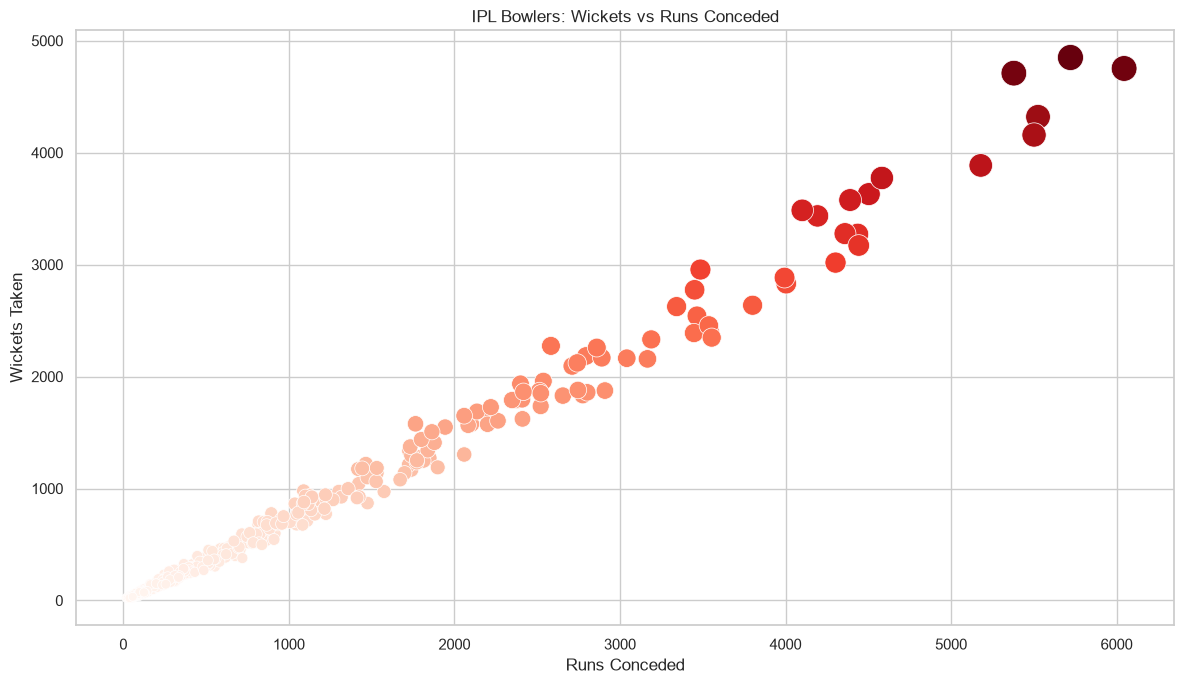

In [21]:
#Top bowlers — wickets vs runs conceded

valid_wickets = deliveries[
    ~deliveries["wicket_type"].isin([
        "", "run out", "retired hurt", "obstructing the field"
    ])
]

bowler_wickets = valid_wickets.groupby("bowler").size().reset_index(name="wickets")

bowler_runs = (
    deliveries.groupby("bowler")["total_runs"]
    .sum()
    .reset_index(name="runs_conceded")
)

bowler_stats = bowler_wickets.merge(bowler_runs, on="bowler")
bowler_stats = bowler_stats[bowler_stats["wickets"] >= 20]

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=bowler_stats,
    x="runs_conceded",
    y="wickets",
    size="wickets",
    hue="wickets",
    palette="Reds",
    sizes=(40, 350),
    legend=False
)

plt.title("IPL Bowlers: Wickets vs Runs Conceded")
plt.xlabel("Runs Conceded")
plt.ylabel("Wickets Taken")
plt.tight_layout()
plt.show()

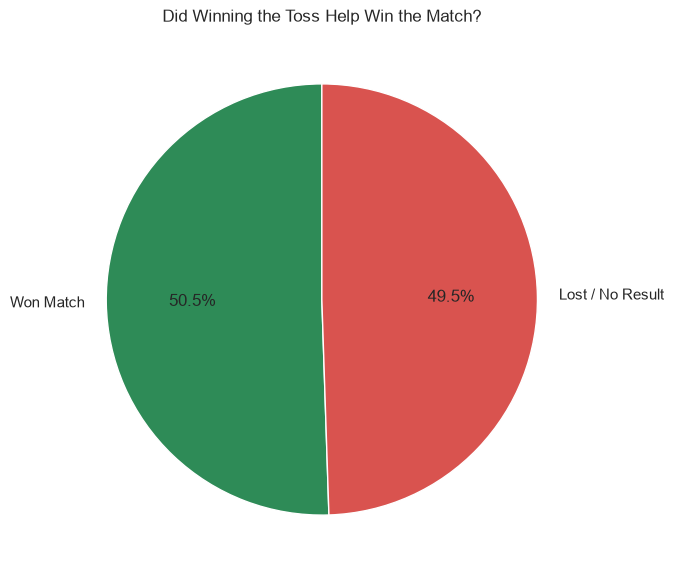

In [22]:
#Match winners after winning toss
toss_advantage = matches.copy()

toss_advantage["won_after_winning_toss"] = (
    toss_advantage["toss_winner"] == toss_advantage["winner"]
)

toss_result = (
    toss_advantage["won_after_winning_toss"]
    .value_counts()
    .rename(index={True: "Won Match", False: "Lost / No Result"})
)

plt.figure(figsize=(7, 7))
plt.pie(
    toss_result.values,
    labels=toss_result.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2E8B57", "#D9534F"]
)

plt.title("Did Winning the Toss Help Win the Match?")
plt.show()

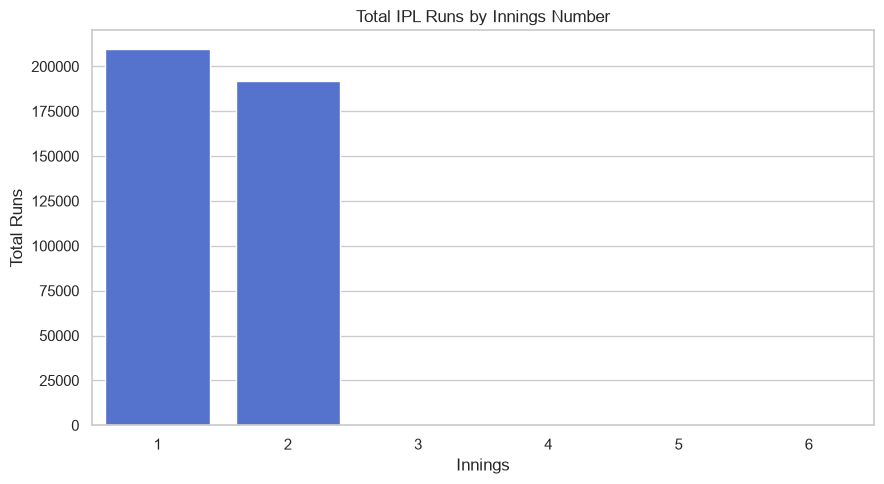

In [23]:
#Runs by innings

innings_runs = (
    deliveries.groupby("innings")["total_runs"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(9, 5))
sns.barplot(data=innings_runs, x="innings", y="total_runs", color="royalblue")

plt.title("Total IPL Runs by Innings Number")
plt.xlabel("Innings")
plt.ylabel("Total Runs")
plt.tight_layout()
plt.show()

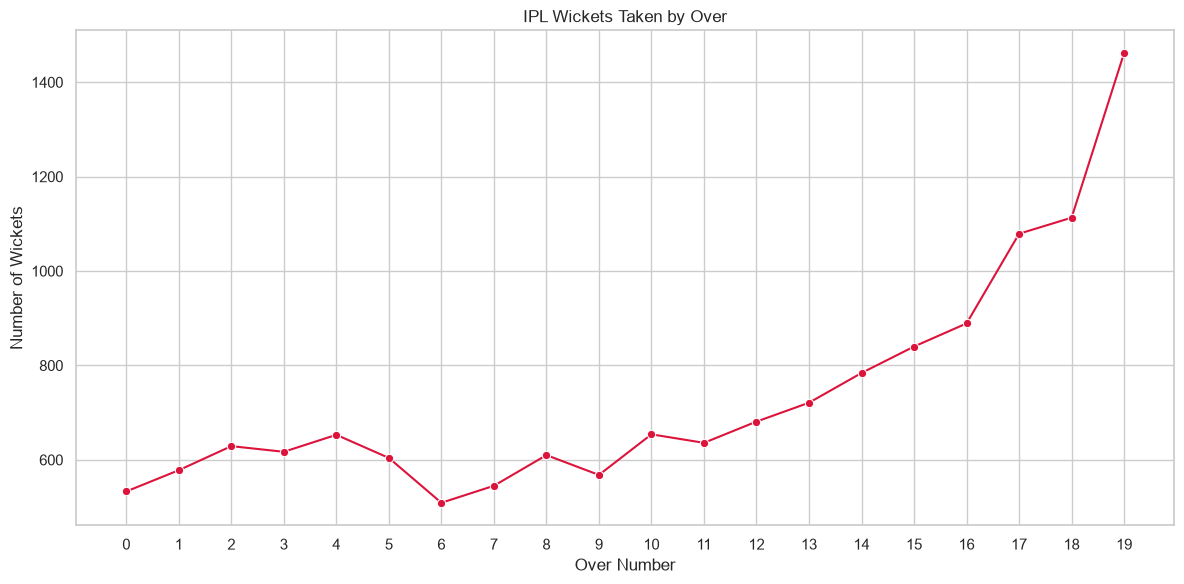

In [24]:
#Wickets by over — which overs are most dangerous?

wicket_deliveries = deliveries[deliveries["wicket_type"].notna() & (deliveries["wicket_type"] != "")]

wickets_by_over = (
    wicket_deliveries.groupby("over_number")
    .size()
    .reset_index(name="wickets")
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=wickets_by_over,
    x="over_number",
    y="wickets",
    marker="o",
    color="crimson"
)

plt.title("IPL Wickets Taken by Over")
plt.xlabel("Over Number")
plt.ylabel("Number of Wickets")
plt.xticks(range(0, 20))
plt.tight_layout()
plt.show()

C:\Users\abhin\AppData\Local\Temp\ipykernel_17932\3539860017.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=boundary_data, x="Boundary", y="Count", palette=["#4C78A8", "#F58518"])


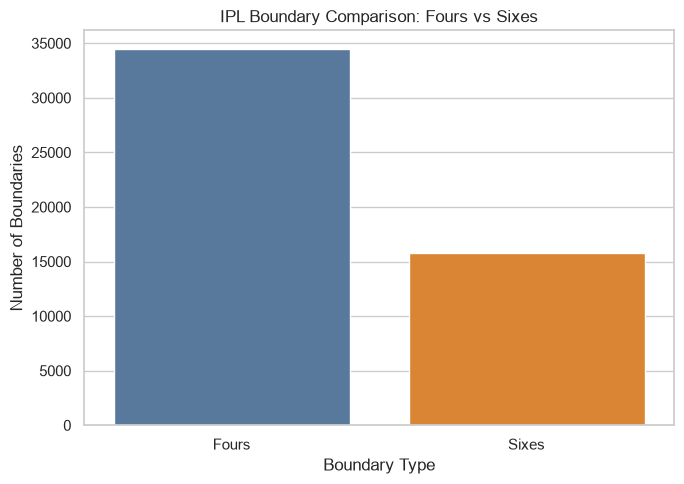

In [25]:
#Boundary comparison — fours versus sixes

boundaries = deliveries["runs_off_bat"].value_counts()

boundary_data = pd.DataFrame({
    "Boundary": ["Fours", "Sixes"],
    "Count": [
        boundaries.get(4, 0),
        boundaries.get(6, 0)
    ]
})

plt.figure(figsize=(7, 5))
sns.barplot(data=boundary_data, x="Boundary", y="Count", palette=["#4C78A8", "#F58518"])

plt.title("IPL Boundary Comparison: Fours vs Sixes")
plt.xlabel("Boundary Type")
plt.ylabel("Number of Boundaries")
plt.tight_layout()
plt.show()